In [1]:
#importing libraries

import geopandas as gpd
import os
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [2]:
#define file paths

shape_files = '/group/moniergrp/dbaral/run_project/input_data/shape_files'
save_path = '/group/moniergrp/dbaral/run_project/output_data/map'


In [4]:
# Load county shapefile

counties = gpd.read_file(os.path.join(shape_files, "CA counties.shp"))

# Select rice-growing counties
rice_counties = counties[counties['NAME'].isin([
    'Butte',
    'Colusa',
    'Glenn',
    'Yolo',
    'Yuba',
    'Placer',
    'Sacramento',
    'San Joaquin',
    'Sutter'
])]



<function matplotlib.pyplot.show(close=None, block=None)>

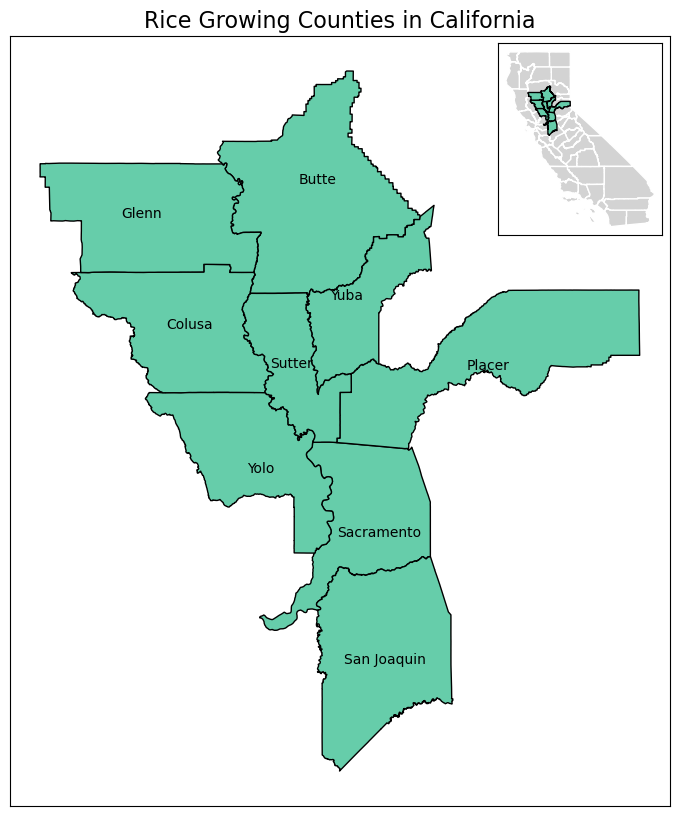

In [10]:
# creating figure

fig, ax = plt.subplots(figsize=(10,10))

#Main map (zoomed counties)

rice_counties.plot(ax=ax, color='#66CDAA', edgecolor='black', linewidth=1)

# Add county labels

for idx, row in rice_counties.iterrows():
    plt.annotate(
        text=row['NAME'],
        xy=(row.geometry.representative_point().x, row.geometry.representative_point().y),
        horizontalalignment='center',
        fontsize=10,
        color='black'
    )

ax.set_xticks([])
ax.set_yticks([])

ax.set_title("Rice Growing Counties in California", fontsize=16)


#inset map (CA all counties)

ax_inset = inset_axes(
    ax,
    width='25%',
    height='25%',
    loc='upper right'
)

#plot all counties in gray
counties.plot(
    ax=ax_inset,
    color='lightgray',
    edgecolor='white'
)

#highlight rice counties
rice_counties.plot(
    ax=ax_inset,
    color='#66CDAA',
    edgecolor='black'
)
ax_inset.set_xticks([])
ax_inset.set_yticks([])

#save the map

save_file = os.path.join(save_path, 'rice_county_map.png')

plt.savefig(save_file, dpi=300, bbox_inches='tight')

plt.show
